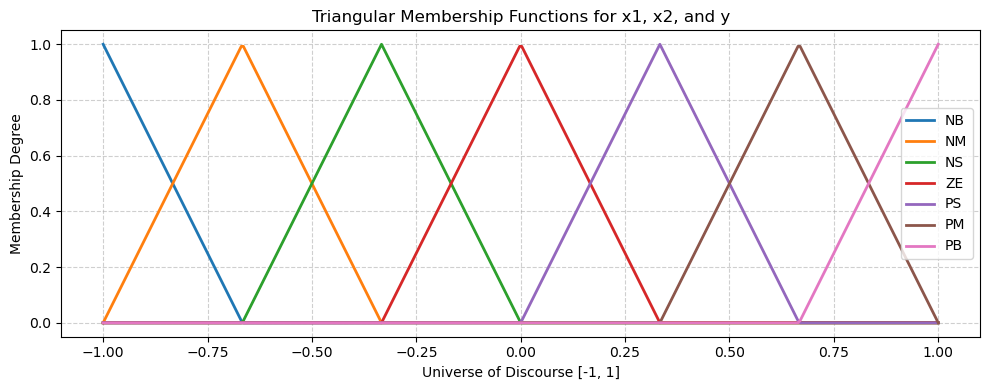

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Dataset Generation
np.random.seed(42)
N = 500
x1 = np.random.uniform(-1, 1, N)
x2 = np.random.uniform(-1, 1, N)
y = np.sin(np.pi * x1) + 0.5 * (x2 ** 2)

# Normalizing y to [-1, 1] for simplicity in defining consistent MFs
y_min, y_max = np.min(y), np.max(y)
y_norm = 2 * ((y - y_min) / (y_max - y_min)) - 1

# 2. Define Membership Functions (7 Triangular MFs)
labels = ['NB', 'NM', 'NS', 'ZE', 'PS', 'PM', 'PB']
centers = np.linspace(-1, 1, 7)
width = 2.0 / 6.0  # Distance between centers

def triangle_mf(x, c, w):
	return np.maximum(0, 1 - np.abs(x - c) / w)

# Plotting the Membership Functions
x_plot = np.linspace(-1, 1, 400)
plt.figure(figsize=(10, 4))
for i, (label, c) in enumerate(zip(labels, centers)):
	plt.plot(x_plot, triangle_mf(x_plot, c, width), label=label, linewidth=2)
plt.title('Triangular Membership Functions for x1, x2, and y')
plt.xlabel('Universe of Discourse [-1, 1]')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('fig3_1.png', dpi=300)
plt.show()

In [2]:
# Dictionary to hold the final rules (Conflict Resolution implicitly handled)
# Key: (x1_label_index, x2_label_index) -> Antecedents
# Value: (y_label_index, degree) -> Consequent and its strength
rule_base = {}

for i in range(N):
	# Calculate memberships for each variable
	mu_x1 = [triangle_mf(x1[i], c, width) for c in centers]
	mu_x2 = [triangle_mf(x2[i], c, width) for c in centers]
	mu_y = [triangle_mf(y_norm[i], c, width) for c in centers]
	
	# Find dominant fuzzy label (argmax)
	idx_x1 = np.argmax(mu_x1)
	idx_x2 = np.argmax(mu_x2)
	idx_y = np.argmax(mu_y)
	
	# Calculate Rule Degree
	degree = mu_x1[idx_x1] * mu_x2[idx_x2] * mu_y[idx_y]
	
	antecedent = (idx_x1, idx_x2)
	
	# Conflict Resolution: Update if the new rule has a higher degree
	if antecedent not in rule_base or degree > rule_base[antecedent][1]:
		rule_base[antecedent] = (idx_y, degree)

In [3]:
print(f"Total number of unique rules generated: {len(rule_base)} (out of possible 49)")
print("-" * 40)
print(f"{'x1 Label':<10} | {'x2 Label':<10} => {'y Label (Consequent)':<20}")
print("-" * 40)

# Display a sample of the lookup table
count = 0
for (ix1, ix2), (iy, deg) in sorted(rule_base.items()):
	if count < 10: # Print first 10 for brevity
		print(f"{labels[ix1]:<10} | {labels[ix2]:<10} => {labels[iy]:<20} (Deg: {deg:.3f})")
	count += 1

Total number of unique rules generated: 49 (out of possible 49)
----------------------------------------
x1 Label   | x2 Label   => y Label (Consequent)
----------------------------------------
NB         | NB         => ZE                   (Deg: 0.617)
NB         | NM         => ZE                   (Deg: 0.639)
NB         | NS         => NS                   (Deg: 0.553)
NB         | ZE         => NS                   (Deg: 0.620)
NB         | PS         => NS                   (Deg: 0.665)
NB         | PM         => ZE                   (Deg: 0.520)
NB         | PB         => ZE                   (Deg: 0.670)
NM         | NB         => NS                   (Deg: 0.550)
NM         | NM         => NM                   (Deg: 0.874)
NM         | NS         => NB                   (Deg: 0.539)


Test RMSE (Normalized Scale): 0.1151


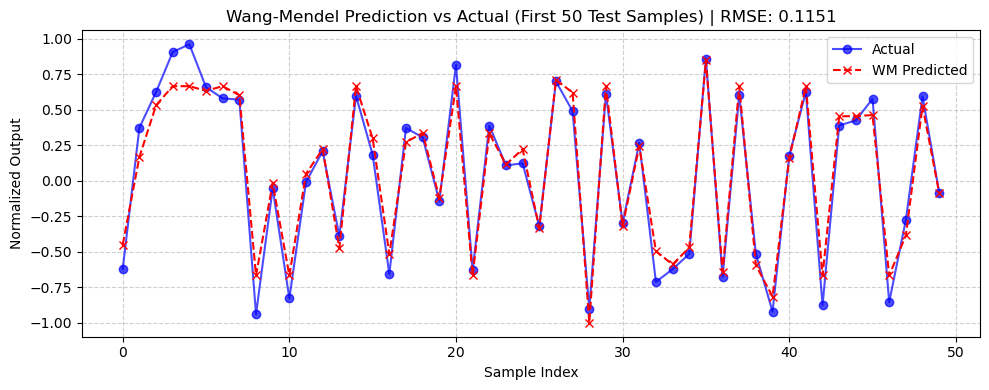

In [7]:
def predict_wang_mendel(x1_test, x2_test):
    y_preds = []
    for i in range(len(x1_test)):
        numerator = 0.0
        denominator = 0.0
        
        # Loop over all rules in the rule base
        for (ix1, ix2), (iy, deg) in rule_base.items():
            # Calculate firing strength
            f_strength = triangle_mf(x1_test[i], centers[ix1], width) * \
                         triangle_mf(x2_test[i], centers[ix2], width)
            
            numerator += f_strength * centers[iy]
            denominator += f_strength
            
        # Avoid division by zero if no rules fire
        if denominator == 0:
            y_preds.append(0) 
        else:
            y_preds.append(numerator / denominator)
            
    return np.array(y_preds)

# Generate 100 new test points
N_test = 100
x1_test = np.random.uniform(-1, 1, N_test)
x2_test = np.random.uniform(-1, 1, N_test)

# Actual outputs mapped to normalized space
y_test_actual_raw = np.sin(np.pi * x1_test) + 0.5 * (x2_test ** 2)
y_test_actual = 2 * ((y_test_actual_raw - y_min) / (y_max - y_min)) - 1

# Predictions
y_test_pred = predict_wang_mendel(x1_test, x2_test)

# Calculate RMSE
rmse = np.sqrt(np.mean((y_test_actual - y_test_pred) ** 2))
print(f"Test RMSE (Normalized Scale): {rmse:.4f}")

# Plotting Actual vs Predicted
plt.figure(figsize=(10, 4))
plt.plot(y_test_actual[:50], 'o-', label='Actual', color='blue', alpha=0.7)
plt.plot(y_test_pred[:50], 'x--', label='WM Predicted', color='red')
plt.title(f'Wang-Mendel Prediction vs Actual (First 50 Test Samples) | RMSE: {rmse:.4f}')
plt.xlabel('Sample Index')
plt.ylabel('Normalized Output')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('fig3_2.png', dpi=300)
plt.show()